# $\text{Recherche}$
## $\text{Modèle de prédiction des affluences des parkings}$

In [11]:
# Import des librairies
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

### Import / traitement des données

In [ ]:
data_file_path = "data/data.csv"

# Chargement des données
data = pd.read_csv(data_file_path)

# Nettoyage des données
data.dropna(inplace=True)  # Suppression des lignes avec des valeurs manquantes
data.drop_duplicates(inplace=True)  # Suppression des doublons

# Encodage des variables
data['idparc'] = data['idparc'].astype('category').cat.codes # Catégoriser l'id du parc
data['etatouverture'] = data['etatouverture'].map({'OUVERT': 1, 'FERME': 0}) # Encoder l'état d'ouverture

# Conserver la date/heure d'origine comme datetime, et créer des colonnes dérivées pour l'heure
last_dt = pd.to_datetime(data['lastupdate'])
data['lastupdate_hour'] = last_dt.dt.hour + last_dt.dt.minute / 60.0  # heure de la journée en float
data['lastupdate_dayofweek'] = last_dt.dt.dayofweek  # jour de la semaine (0= lundi, 6= dimanche)
data.drop('lastupdate', axis=1, inplace=True)

# Transformation de capacitesoliste et jrdinfosoliste en pourcentage d'occupation
data['occupation_rate'] = data['jrdinfosoliste'] / data['capacitesoliste']
capacite_soliste = data['capacitesoliste'].values
data.drop(['capacitesoliste', 'jrdinfosoliste'], axis=1, inplace=True)

print(data.describe())
print(data.head())

              idparc  etatouverture  lastupdate_hour  lastupdate_dayofweek  \
count  150688.000000  150688.000000    150688.000000         150688.000000   
mean        3.500000       0.741187        10.993283              2.761839   
std         2.291295       0.437984         6.377320              1.932829   
min         0.000000       0.000000         0.000000              0.000000   
25%         1.750000       0.000000         5.450000              1.000000   
50%         3.500000       1.000000        11.016667              3.000000   
75%         5.250000       1.000000        16.416667              4.000000   
max         7.000000       1.000000        23.983333              6.000000   

       lastupdate_month  occupation_rate  
count     150688.000000    150688.000000  
mean          10.729189         0.433481  
std            0.444380         0.365184  
min           10.000000         0.000000  
25%           10.000000         0.000000  
50%           11.000000         0.45509

### Statistiques

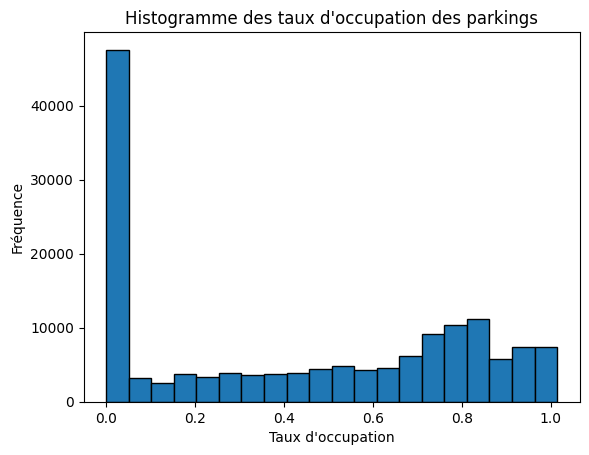

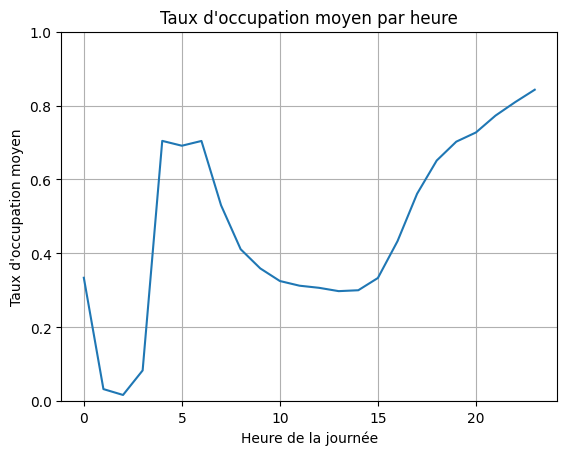

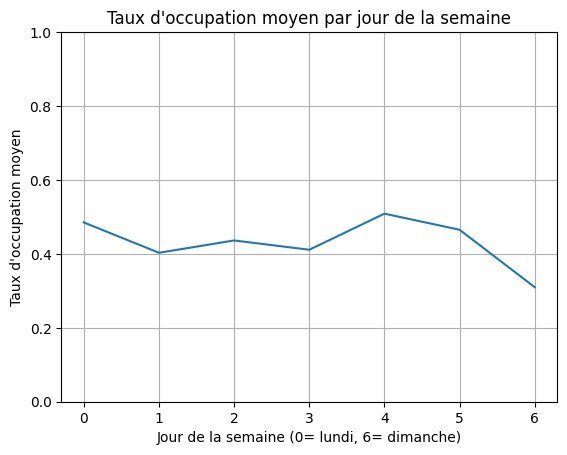

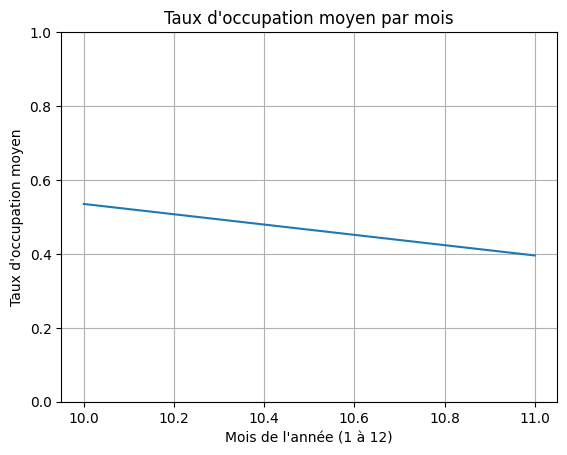

In [ ]:
# Histogramme des taux d'occupation
plt.hist(data['occupation_rate'].to_numpy(), bins=20, edgecolor='black')
plt.title('Histogramme des taux d\'occupation des parkings')
plt.xlabel('Taux d\'occupation')
plt.ylabel('Fréquence')
plt.show()

# Taux d'occupation par heure
# Utiliser des numpy arrays explicites pour éviter les erreurs de typage lors de l'appel à matplotlib
data['hour'] = last_dt.dt.hour  # heure entière (pour groupby)
hourly_occupation = data.groupby('hour')['occupation_rate'].mean()
data.drop('hour', axis=1, inplace=True)
x = hourly_occupation.index.to_numpy()
y = hourly_occupation.to_numpy()

plt.plot(x, y)
plt.title('Taux d\'occupation moyen par heure')
plt.xlabel('Heure de la journée')
plt.ylabel('Taux d\'occupation moyen')
plt.ylim(0, 1)
plt.grid()
plt.show()

# Taux d'occupation par jour de la semaine
daily_occupation = data.groupby('lastupdate_dayofweek')['occupation_rate'].mean()
x = daily_occupation.index.to_numpy()
y = daily_occupation.to_numpy()

plt.plot(x, y)
plt.title('Taux d\'occupation moyen par jour de la semaine')
plt.xlabel('Jour de la semaine (0= lundi, 6= dimanche)')
plt.ylabel('Taux d\'occupation moyen')
plt.ylim(0, 1)
plt.grid()
plt.show()

### Séparation des jeux de données

In [20]:
train_set, test_set = train_test_split(data, test_size=0.2, random_state=1)
X_train = train_set.drop('occupation_rate', axis=1)
y_train = train_set['occupation_rate']

X_test = test_set.drop('occupation_rate', axis=1)
y_test = test_set['occupation_rate']

### **Régression Linéaire**

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
# Seuillage des prédictions
predictions = [min(max(0, predictions[i]), capacite_soliste[i]) for i in range(len(predictions))]

y_true = y_test.values
y_pred = np.array(predictions)

# Conversion en pourcentage
y_true = y_true*100  
y_pred = y_pred*100

sample = 10
for i in range(sample):
    print(f"Vrai: {y_true[i]:.2f}%, Prédit: {y_pred[i]:.2f}%")

Vrai: 20.63%, Prédit: 55.25%
Vrai: 85.25%, Prédit: 60.40%
Vrai: 73.42%, Prédit: 62.15%
Vrai: 84.99%, Prédit: 57.67%
Vrai: 83.24%, Prédit: 67.02%
Vrai: 0.00%, Prédit: 1.77%
Vrai: 89.69%, Prédit: 62.72%
Vrai: 2.15%, Prédit: 56.21%
Vrai: 18.93%, Prédit: 58.89%
Vrai: 49.09%, Prédit: 62.70%


#### Évaluation

MSE : 658.6015661126112
RMSE : 25.663233742313363
MAE : 19.36311498263332
R² : 0.5033822371810661


C:\Users\theo_\AppData\Local\Temp\ipykernel_27088\1956221265.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = df.groupby("bin")["error"].mean().reset_index()


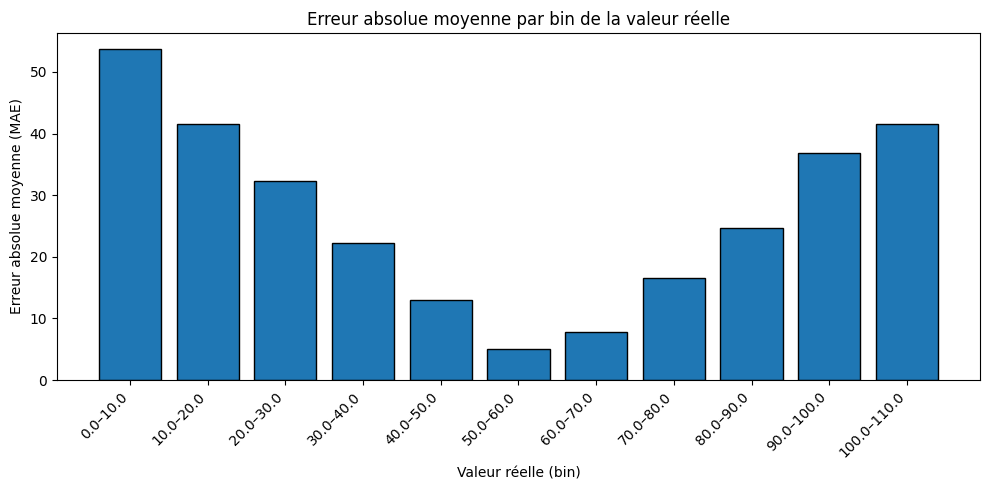

      label     error
   0.0–10.0 53.669750
  10.0–20.0 41.497811
  20.0–30.0 32.294862
  30.0–40.0 22.265550
  40.0–50.0 12.936183
  50.0–60.0  4.970516
  60.0–70.0  7.800917
  70.0–80.0 16.495606
  80.0–90.0 24.615921
 90.0–100.0 36.888149
100.0–110.0 41.612890


In [22]:
# Évaluation du modèle
mse = mean_squared_error(y_true, y_pred)
print("MSE :", mse)
print("RMSE :", np.sqrt(mse))
print("MAE :", sum(abs(y_true[i] - y_pred[i]) for i in range(len(y_pred))) / len(y_pred))
print("R² :", model.score(X_test, y_test))

# Histogramme des erreurs absolues moyennes en fonction de la valeur réelle
errors = np.abs(y_true - y_pred)

bin_width = 10
min_val = np.floor(y_true.min() / bin_width) * bin_width
max_val = np.ceil(y_true.max() / bin_width) * bin_width
bins = np.arange(min_val, max_val + bin_width, bin_width)

# Calcul de la MAE par bin
df = pd.DataFrame({
    "y_true": y_true,
    "error": errors
})
df["bin"] = pd.cut(df["y_true"], bins=bins, right=True)

mae_by_bin = df.groupby("bin")["error"].mean().reset_index()

mae_by_bin["label"] = mae_by_bin["bin"].apply(lambda iv: f"{iv.left:.1f}–{iv.right:.1f}") # labels
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(mae_by_bin["label"], mae_by_bin["error"], width=0.8, color="C0", edgecolor="k")
ax.set_xlabel("Valeur réelle (bin)")
ax.set_ylabel("Erreur absolue moyenne (MAE)")
ax.set_title("Erreur absolue moyenne par bin de la valeur réelle")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Affichage optionnel des valeurs numériques
print(mae_by_bin[["label", "error"]].to_string(index=False))

### **Random Forest**

In [23]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
# Seuillage des prédictions
predictions = [min(max(0, predictions[i]), capacite_soliste[i]) for i in range(len(predictions))]
y_true = y_test.values
y_pred = np.array(predictions)
# Conversion en pourcentage
y_true = y_true*100
y_pred = y_pred*100

sample = 10
for i in range(sample):
    print(f"Vrai: {y_true[i]:.2f}%, Prédit: {y_pred[i]:.2f}%")

Vrai: 20.63%, Prédit: 28.57%
Vrai: 85.25%, Prédit: 77.00%
Vrai: 73.42%, Prédit: 73.39%
Vrai: 84.99%, Prédit: 84.99%
Vrai: 83.24%, Prédit: 81.59%
Vrai: 0.00%, Prédit: 0.00%
Vrai: 89.69%, Prédit: 91.76%
Vrai: 2.15%, Prédit: 28.27%
Vrai: 18.93%, Prédit: 27.58%
Vrai: 49.09%, Prédit: 26.87%


#### Évaluation

MSE : 144.6177022569006
RMSE : 12.025710052088426
MAE : 6.389453472110761
R² : 0.8913246709523305


C:\Users\theo_\AppData\Local\Temp\ipykernel_27088\1956221265.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_by_bin = df.groupby("bin")["error"].mean().reset_index()


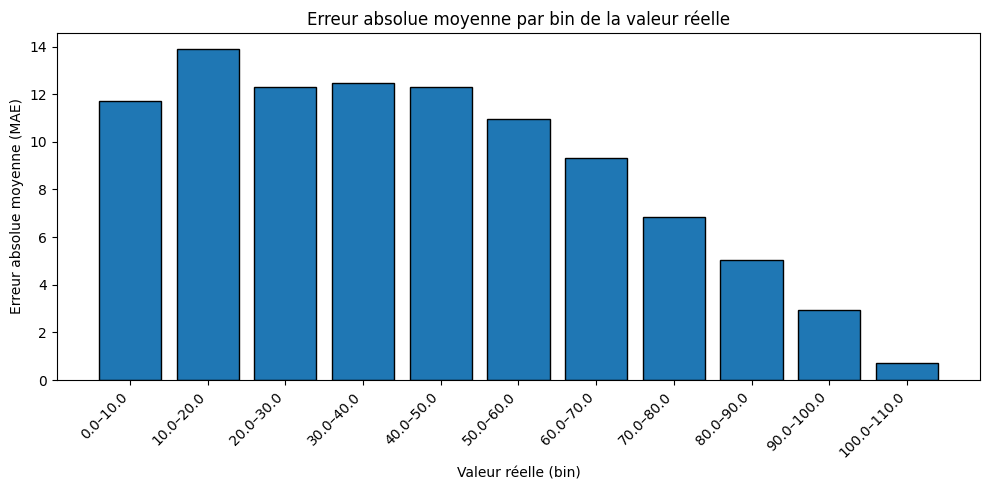

      label     error
   0.0–10.0 11.731489
  10.0–20.0 13.882619
  20.0–30.0 12.290163
  30.0–40.0 12.450599
  40.0–50.0 12.303167
  50.0–60.0 10.965320
  60.0–70.0  9.307630
  70.0–80.0  6.851400
  80.0–90.0  5.018757
 90.0–100.0  2.939298
100.0–110.0  0.725847


In [24]:
# Évaluation du modèle
mse = mean_squared_error(y_true, y_pred)
print("MSE :", mse)
print("RMSE :", np.sqrt(mse))
print("MAE :", sum(abs(y_true[i] - y_pred[i]) for i in range(len(y_pred))) / len(y_pred))
print("R² :", model.score(X_test, y_test))

# Histogramme des erreurs absolues moyennes en fonction de la valeur réelle
errors = np.abs(y_true - y_pred)

bin_width = 10
min_val = np.floor(y_true.min() / bin_width) * bin_width
max_val = np.ceil(y_true.max() / bin_width) * bin_width
bins = np.arange(min_val, max_val + bin_width, bin_width)

# Calcul de la MAE par bin
df = pd.DataFrame({
    "y_true": y_true,
    "error": errors
})
df["bin"] = pd.cut(df["y_true"], bins=bins, right=True)

mae_by_bin = df.groupby("bin")["error"].mean().reset_index()

mae_by_bin["label"] = mae_by_bin["bin"].apply(lambda iv: f"{iv.left:.1f}–{iv.right:.1f}") # labels
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(mae_by_bin["label"], mae_by_bin["error"], width=0.8, color="C0", edgecolor="k")
ax.set_xlabel("Valeur réelle (bin)")
ax.set_ylabel("Erreur absolue moyenne (MAE)")
ax.set_title("Erreur absolue moyenne par bin de la valeur réelle")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Affichage optionnel des valeurs numériques
print(mae_by_bin[["label", "error"]].to_string(index=False))